# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

Data Validation

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('recipe_site_traffic_2212.csv')
print(df.shape)         
print(df.dtypes)
print(df.isna().sum())

(947, 8)
recipe            int64
calories        float64
carbohydrate    float64
sugar           float64
protein         float64
category         object
servings         object
high_traffic     object
dtype: object
recipe            0
calories         52
carbohydrate     52
sugar            52
protein          52
category          0
servings          0
high_traffic    373
dtype: int64


Combined 'Chicken Breast' and 'Chicken'

In [2]:
print(df['category'].unique())
print()
print(df['category'].value_counts())

['Pork' 'Potato' 'Breakfast' 'Beverages' 'One Dish Meal' 'Chicken Breast'
 'Lunch/Snacks' 'Chicken' 'Vegetable' 'Meat' 'Dessert']

Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: category, dtype: int64


In [3]:
df['category'] = df['category'].replace({'Chicken Breast': 'Chicken'})
print(df['category'].value_counts())

Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: category, dtype: int64


Combined the '4 as a snack' with 4 and '6 as a snack' with 6

In [4]:
print(df['servings'].unique())
print()
print(df['servings'].value_counts())

['6' '4' '1' '2' '4 as a snack' '6 as a snack']

4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: servings, dtype: int64


In [5]:
df['servings'] = df['servings'].replace({'4 as a snack': '4', '6 as a snack': '6'})
df['servings'] = df['servings'].astype(int)
print(df['servings'].value_counts())

4    391
6    198
2    183
1    175
Name: servings, dtype: int64


Filled Na with low as hinted from the e-mail

In [6]:
print(df['high_traffic'].unique())
print()
print(df['high_traffic'].value_counts())

['High' nan]

High    574
Name: high_traffic, dtype: int64


In [7]:
df['high_traffic'] = df['high_traffic'].fillna('Low')
print(df['high_traffic'].value_counts())

High    574
Low     373
Name: high_traffic, dtype: int64


In [8]:
# check how many of the 52 dropped rows were High vs Low, before dropping
missing_nutrition = df[df['calories'].isna()]
print(missing_nutrition['high_traffic'].value_counts(dropna=False))

High    39
Low     13
Name: high_traffic, dtype: int64


Ided all the Na as the same line

In [9]:
missing_calories = df[df['calories'].isna()]
print(missing_calories[['calories','carbohydrate','sugar','protein']].isna().sum())

calories        52
carbohydrate    52
sugar           52
protein         52
dtype: int64


dropping Na is no risk of introducing "made up" values that could distort the true nutrition patterns

In [10]:
df = df.dropna(subset=['calories','carbohydrate','sugar','protein'])

Exploratory Analysis

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Category')

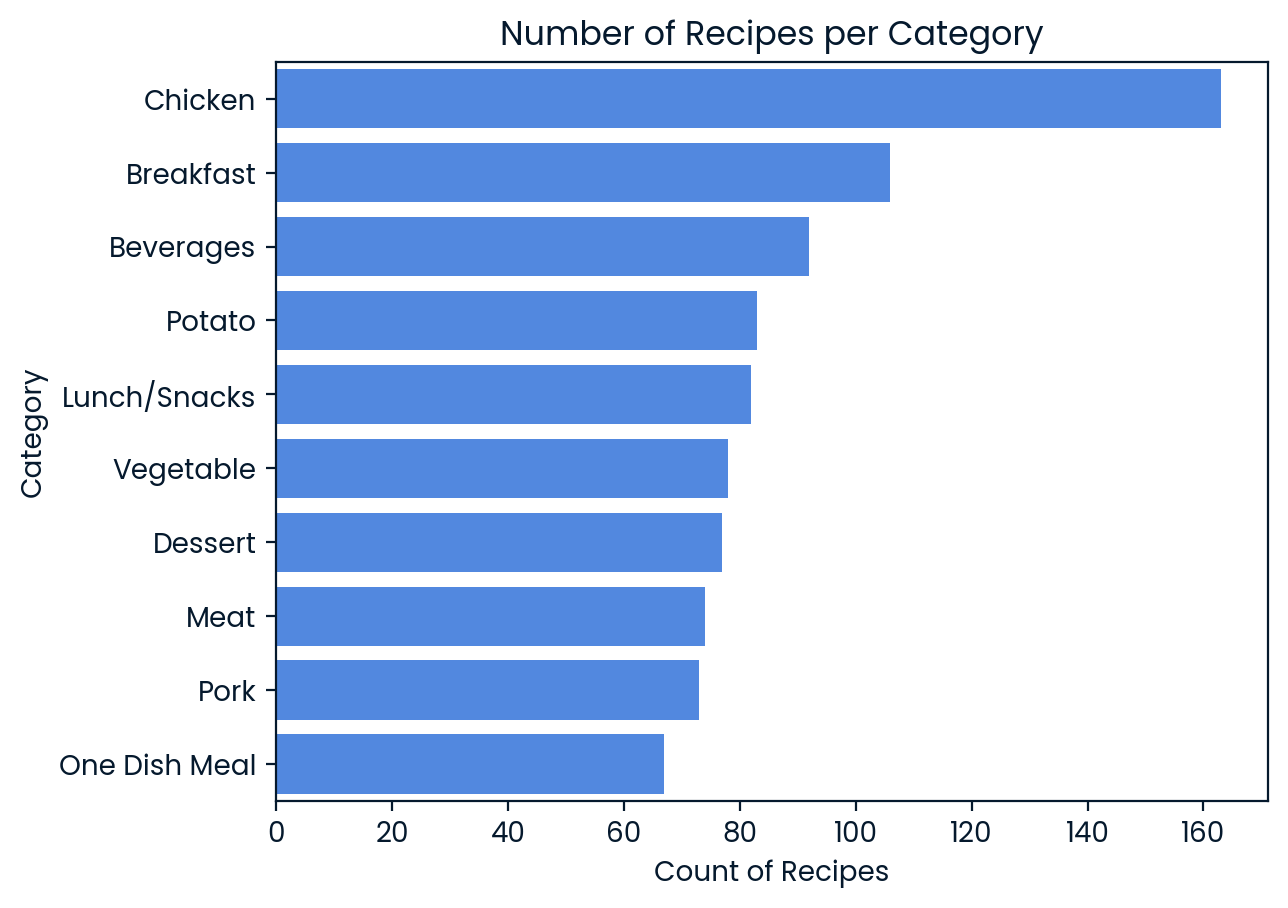

In [12]:
# Chart 1: category count
order = df['category'].value_counts().index
sns.countplot(y='category', data=df, order=order, color='#3b82f6')
plt.title('Number of Recipes per Category')
plt.xlabel('Count of Recipes')
plt.ylabel('Category')

Text(0.5, 0, 'Calories')

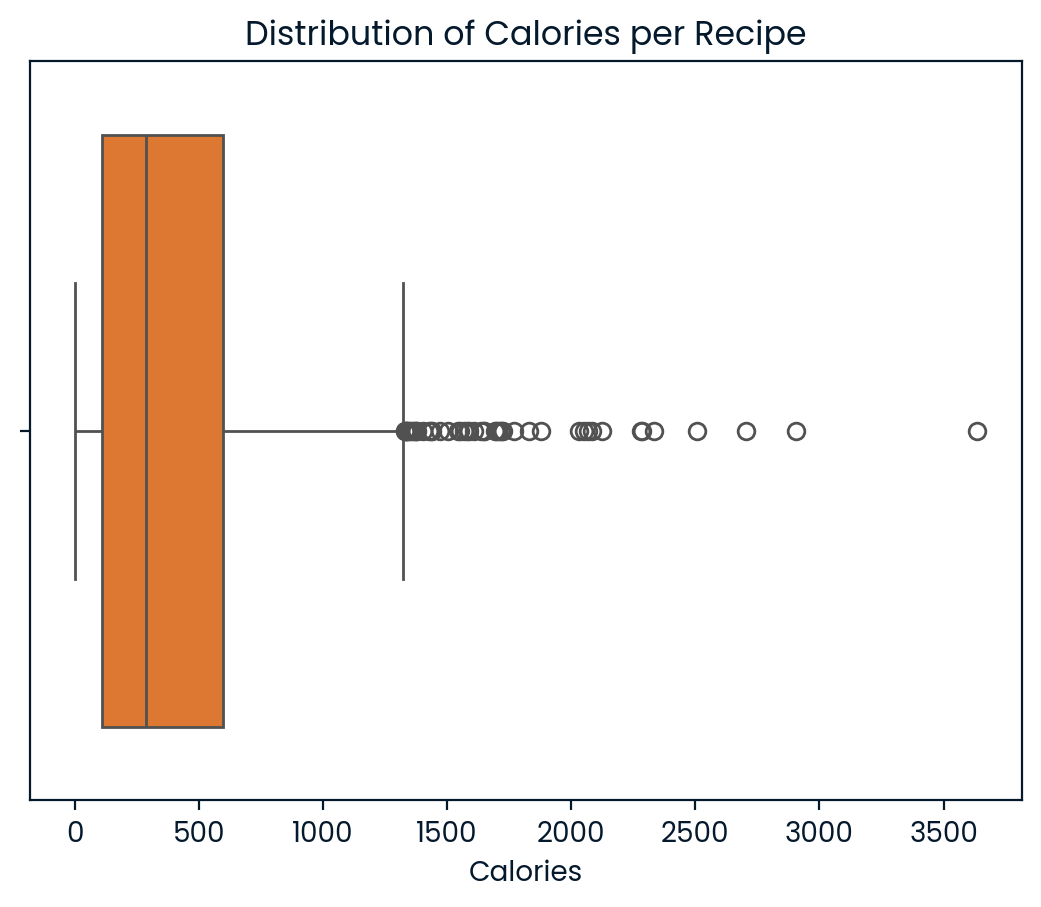

In [13]:
# Chart 2: calories box plot
sns.boxplot(x=df['calories'], color='#f97316')
plt.title('Distribution of Calories per Recipe')
plt.xlabel('Calories')

In [14]:
top10 = df.sort_values('calories', ascending=False).head(10)
print(top10[['recipe','category','calories']])

     recipe       category  calories
925     926        Chicken   3633.16
124     125           Pork   2906.01
226     227           Pork   2703.12
71       72        Chicken   2508.47
907     908  One Dish Meal   2332.32
939     940        Chicken   2283.29
356     357  One Dish Meal   2282.60
55       56           Pork   2122.24
97       98  One Dish Meal   2081.69
781     782         Potato   2068.07


- I picked a Bar plot to depict category as it is a categorical column with a manageable number of groups (10), so a chart showing how many recipes fall into each category would clearly demonstrate one "characteristic" of the data. The categories are reasonably balanced overall , with Chicken bening by far the most common category
- Then i  Box plot picked calories because it'll clearly show the outliers and as we find out it is right-skewed there are a some very high-calorie recipes pulling the distribution out. The mean should be noticeably higher than the median

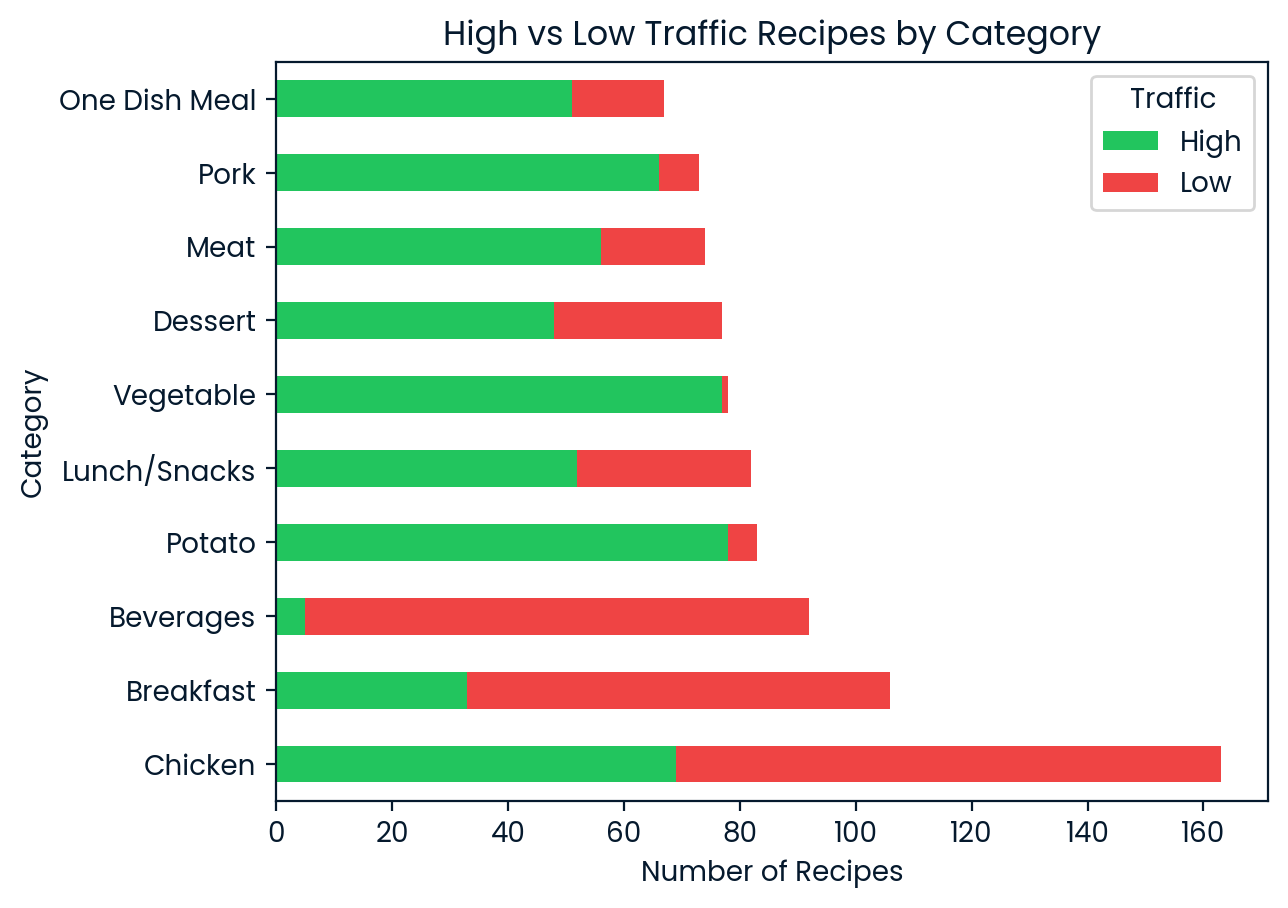

In [15]:
ct = pd.crosstab(df['category'], df['high_traffic'])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

ct.plot(kind='barh', stacked=True, color=['#22c55e','#ef4444'])
plt.title('High vs Low Traffic Recipes by Category')
plt.xlabel('Number of Recipes')
plt.ylabel('Category')
plt.legend(title='Traffic')

Vegetable, Potato, Pork: these categories are reliably high-traffic

Model Development

We have a binary classification problem. I'm predicting whether a recipe's traffic will be High or Low

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [17]:
# create the numeric target
df['target'] = (df['high_traffic'] == 'High').astype(int)

# turn category into dummy columns (we need numbers, not text)
X = pd.get_dummies(df[['calories','carbohydrate','sugar','protein','servings','category']],
                    columns=['category'], drop_first=True)
y = df['target']  # 1 = High, 0 = Low

In [18]:
#spliting the sample
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [19]:
print(f"Test set size: {len(X_test)} recipes")

Test set size: 179 recipes


In [20]:
#columns are on different scale so scalling is needed
num_cols = ['calories','carbohydrate','sugar','protein','servings']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Base model: Logistic Regression becauce of strong linear relationship between category and traffic. Also it is simple, fast and interpretable.

In [21]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

<AxesSubplot: >

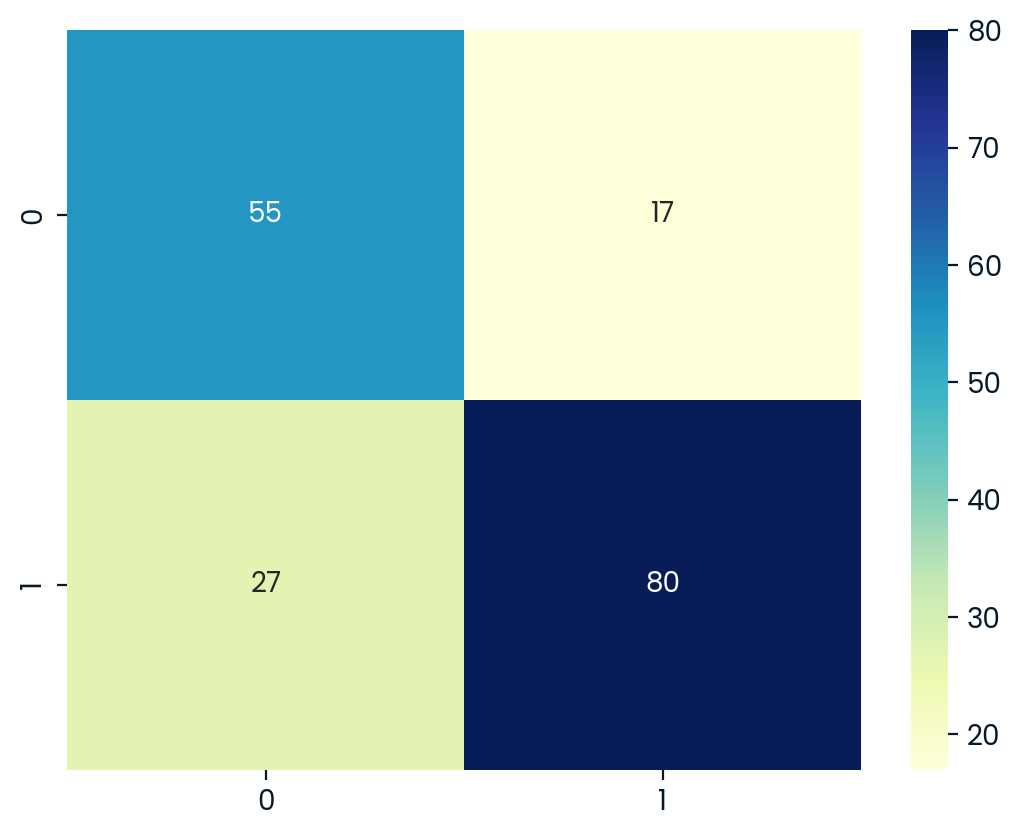

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

cnf_matrix_d = confusion_matrix(y_test, y_pred)
sns.heatmap(pd.DataFrame(cnf_matrix_d), annot=True, cmap="YlGnBu", fmt="g")

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.76      0.71        72
           1       0.82      0.75      0.78       107

    accuracy                           0.75       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.76      0.75      0.76       179



Findings: 
- correctly predict high traffic recipes at least 80% of the time
- model is doing reasonably well overall
- 82% precision

Second model: Decision Tree as a comparison model because it does rule-based splits well suited to the very clear category-based pattern in the data.

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree - no scaling needed! trees split on raw thresholds, not distances
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)


<AxesSubplot: >

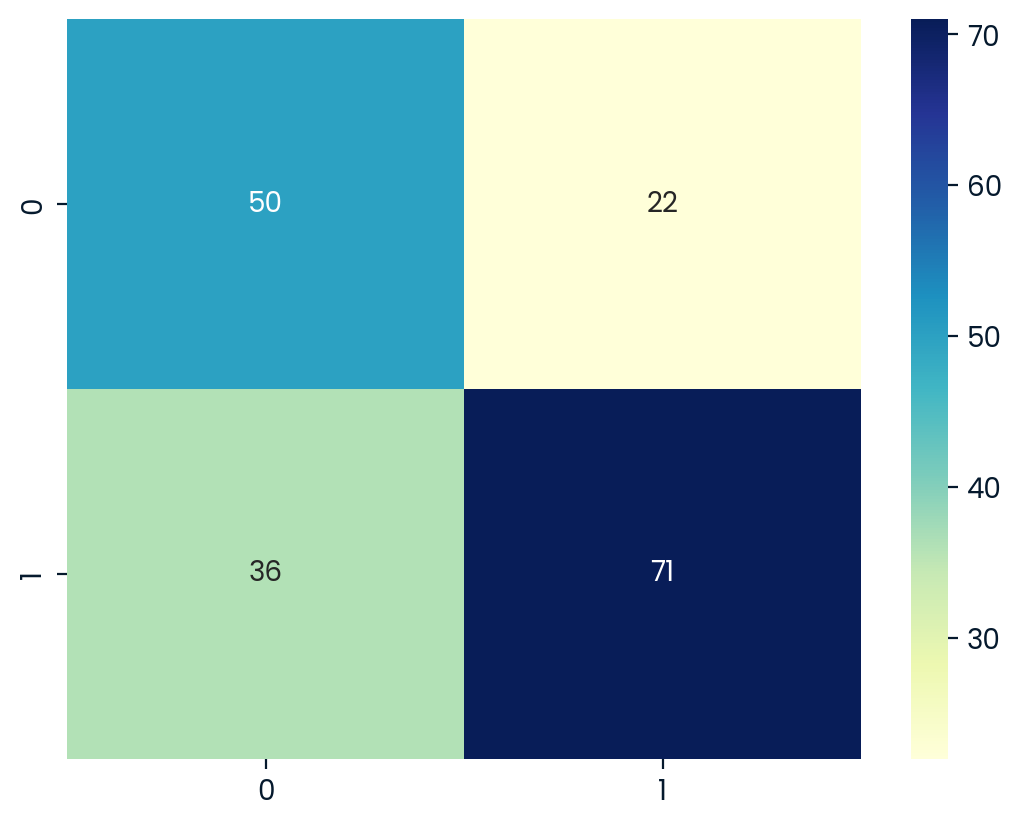

In [25]:
cnf_matrix_d = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(pd.DataFrame(cnf_matrix_d), annot=True, cmap="YlGnBu", fmt="g")

In [26]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.58      0.69      0.63        72
           1       0.76      0.66      0.71       107

    accuracy                           0.68       179
   macro avg       0.67      0.68      0.67       179
weighted avg       0.69      0.68      0.68       179



Findings: 
- worst performance than previus

Third model: XGBoost as an atempt to better the previous model

In [27]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

<AxesSubplot: >

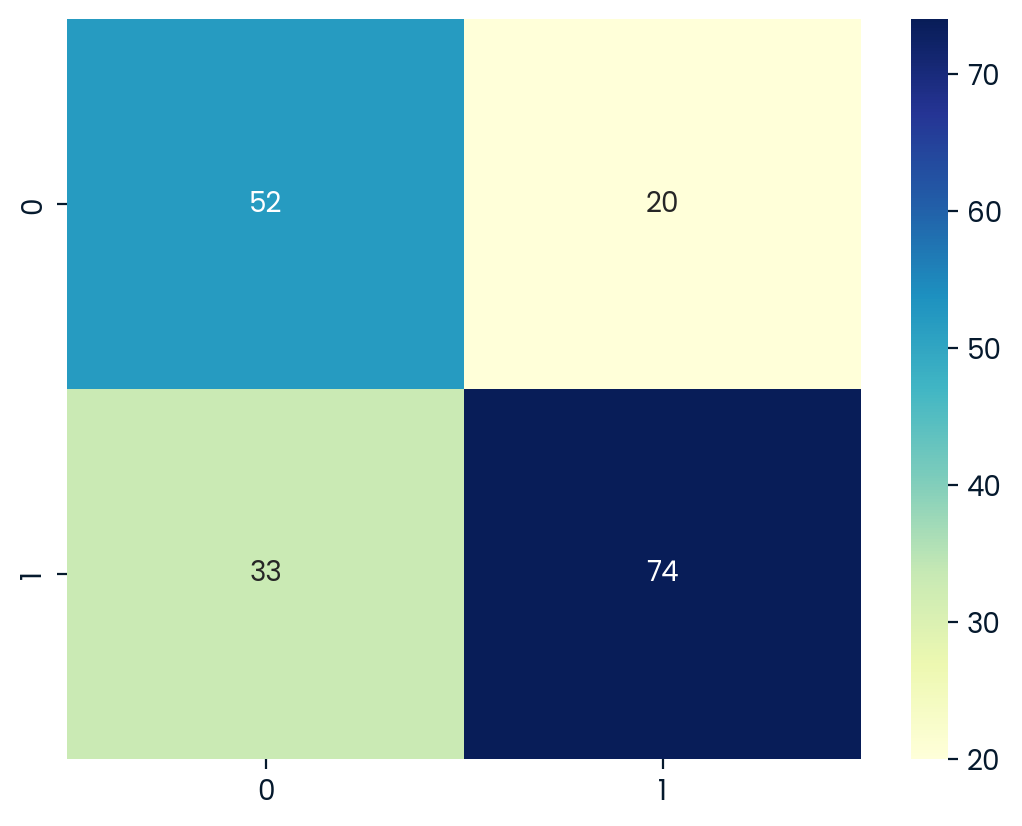

In [28]:
cnf_matrix_d = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(pd.DataFrame(cnf_matrix_d), annot=True, cmap="YlGnBu", fmt="g")

In [29]:
print(classification_report(y_test, y_pred_xgb))



              precision    recall  f1-score   support

           0       0.61      0.72      0.66        72
           1       0.79      0.69      0.74       107

    accuracy                           0.70       179
   macro avg       0.70      0.71      0.70       179
weighted avg       0.72      0.70      0.71       179



Findings:
- No critical changes

Logistic Regression performed best across every metric. 

Business Metrics

In [30]:
baseline_rate = (df['high_traffic'] == 'High').mean()
print(f"Baseline High-traffic rate: {baseline_rate:.3f} ({baseline_rate*100:.1f}%)")

Baseline High-traffic rate: 0.598 (59.8%)


Since we don't have data on the Product Manager's specific historical picks, I'm using the overall dataset's High-traffic rate (59.8%) as a reasonable proxy for random/uninformed selection, a conservative baseline to compare the model against. It's possible the Product Manager's manual picks already do somewhat better than random chance, since they're using their own judgment, but this dataset doesn't let us measure that directly

My Logistic Regression model achieves 82.5% precision when predicting which recipes will be High traffic although it is an estimate based on a single train/test split of historical data (179 test recipes)

Final Summary & Recommendations

1. The model meets the goal — 82.5% precision, beating the Product Manager's 
80% target and the 59.8% baseline.

2. Category alone is a strong signal: Vegetable, Potato, and Pork recipes 
are almost always High traffic (90%+); Beverages and Breakfast rarely are.

3. Recommendation: implement the model to rank candidate recipes by 
predicted probability of High traffic, letting the Product Manager pick 
from a pre-filtered, likely-successful shortlist.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation